In [1]:
# setup
import numpy as np
import matplotlib.pyplot as plt
import math
import cv2
import argparse
import json


from pathlib import Path

from scipy.signal import convolve2d
from skimage.io import imread
from skimage.util import img_as_float
from skimage import color

from time import perf_counter


In [2]:
img_dir = Path("img")
out_dir = Path("out")

out_dir.mkdir(exist_ok=True)

In [13]:
# 1.1
def conv_4_loop(image, kernel):
    image = np.asarray(image, dtype=np.float64)
    kernel = np.asarray(kernel, dtype=np.float64)
    height, width = image.shape
    k_height, k_width = kernel.shape

    pad_top = k_height // 2
    pad_bottom = (k_height - 1) // 2
    pad_left = k_width // 2
    pad_right = (k_width - 1) // 2

    padded = np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right)), mode="constant", constant_values=0)
    flipped = kernel[::-1, ::-1]
    result = np.zeros((height, width), dtype=np.float64)

    for y in range(height):
        for x in range(width):
            total = 0.0
            
            for ky in range(k_height):
                for kx in range(k_width):
                    result[y, x] += padded[y + ky, x + kx] * flipped[ky, kx]
    return result   

def conv_2_loop(image, kernel):
    image = np.asarray(image, dtype=np.float64)
    kernel = np.asarray(kernel, dtype=np.float64)
    height, width = image.shape
    k_height, k_width = kernel.shape

    pad_top = k_height // 2
    pad_bottom = (k_height - 1) // 2
    pad_left = k_width // 2
    pad_right = (k_width - 1) // 2

    padded = np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right)), mode="constant", constant_values=0)
    flipped = kernel[::-1, ::-1]
    result = np.zeros((height, width), dtype=np.float64)

    for y in range(height):
        for x in range(width):
            result[y, x] = np.sum(padded[y:y+k_height, x:x+k_width] * flipped)

    return result

image shape: (1280, 1280)


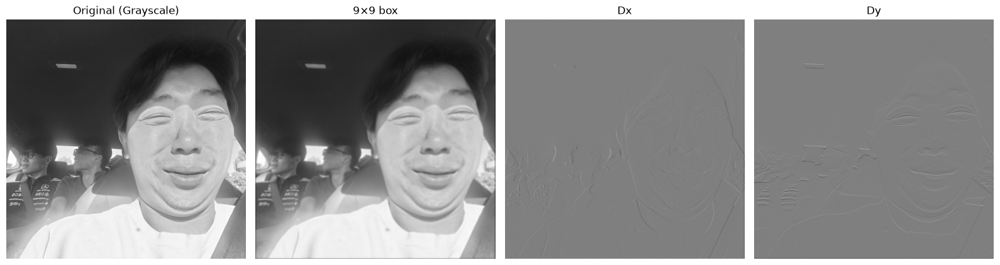

In [17]:
# 1.1 run
img = img_as_float(imread("img/me_1.jpg"))

if img.ndim == 2:
    gray = img
elif img.ndim == 3 and img.shape[-1] in (3, 4):
    gray = color.rgb2gray(img[..., :3])
else:
    raise ValueError("[1.1] expecting a grayscale, rgb, or rgba image")

print("image shape:", gray.shape)

box = np.ones((9, 9), dtype=np.float64) / 81
Dx = np.array([[1, 0, -1]], dtype=np.float64)
Dy = np.array([[1], [0], [-1]], dtype=np.float64)

box_result = conv_2_loop(gray, box)
dx_result = conv_2_loop(gray, Dx)
dy_result = conv_2_loop(gray, Dy)

d_limit = max(np.max(np.abs(dx_result)), np.max(np.abs(dy_result)), 1e-12)
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

axes[0].imshow(gray, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original (Grayscale)")

axes[1].imshow(box_result, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("9×9 box")

axes[2].imshow(dx_result, cmap="gray", vmin=-d_limit, vmax=d_limit)
axes[2].set_title("Dx")

axes[3].imshow(dy_result, cmap="gray", vmin=-d_limit, vmax=d_limit)
axes[3].set_title("Dy")

for ax in axes:
    ax.axis("off")

plt.imsave(out_dir / "original.png", gray, cmap="gray", vmin=0, vmax=1)
plt.imsave(out_dir / "box_filtered.png", box_result, cmap="gray", vmin=0, vmax=1)

plt.imsave(out_dir / "derivative_x.png", dx_result, cmap="gray", vmin=-d_limit, vmax=d_limit)
plt.imsave(out_dir / "derivative_y.png", dy_result, cmap="gray", vmin=-d_limit, vmax=d_limit)

fig.savefig(out_dir / "1_1_comparison.png", dpi=150, bbox_inches="tight")

plt.tight_layout()
plt.show()

In [27]:
# small test image array
test_image = np.arange(1, 21, dtype=np.float64).reshape(4, 5)

# small asymmetric test kernel to catch missed kernel flips
test_kernel = np.array([
    [0, 1, 2],
    [3, 4, 5],
    [6, 7, 8],
], dtype=np.float64)

result_four = conv_4_loop(test_image, test_kernel)
result_two = conv_2_loop(test_image, test_kernel)

result_scipy = convolve2d(test_image, test_kernel, mode="same", boundary="fill", fillvalue=0)

# allow small differences from floating-point summation order
np.testing.assert_allclose(result_four, result_scipy, atol=1e-12)
np.testing.assert_allclose(result_two, result_scipy, atol=1e-12)

print("Four-loop maximum error:", np.max(np.abs(result_four - result_scipy)))
print("Two-loop maximum error:", np.max(np.abs(result_two - result_scipy)))

Four-loop maximum error: 0.0
Two-loop maximum error: 0.0


In [26]:
methods = {
    "Four loops": conv_4_loop,
    "Two loops": conv_2_loop,
    "SciPy": lambda image, kernel: convolve2d(image, kernel, mode="same", boundary="fill", fillvalue=0),
}

reference = methods["SciPy"](gray, box)

for name, method in methods.items():
    timings = []

    # Repeat to reduce the influence of a single timing fluctuation.
    for _ in range(3):
        start = perf_counter()
        result = method(gray, box)
        timings.append(perf_counter() - start)

    error = np.max(np.abs(result - reference))

    print(f"{name:12s} | " f"median time: {np.median(timings):.6f} s | " f"maximum error: {error:.3e}")

Four loops   | median time: 54.684548 s | maximum error: 2.665e-15
Two loops    | median time: 4.922916 s | maximum error: 7.772e-16
SciPy        | median time: 0.151020 s | maximum error: 0.000e+00


shape: (542, 540)
intensity range: 0.027450980392156862 - 1.0


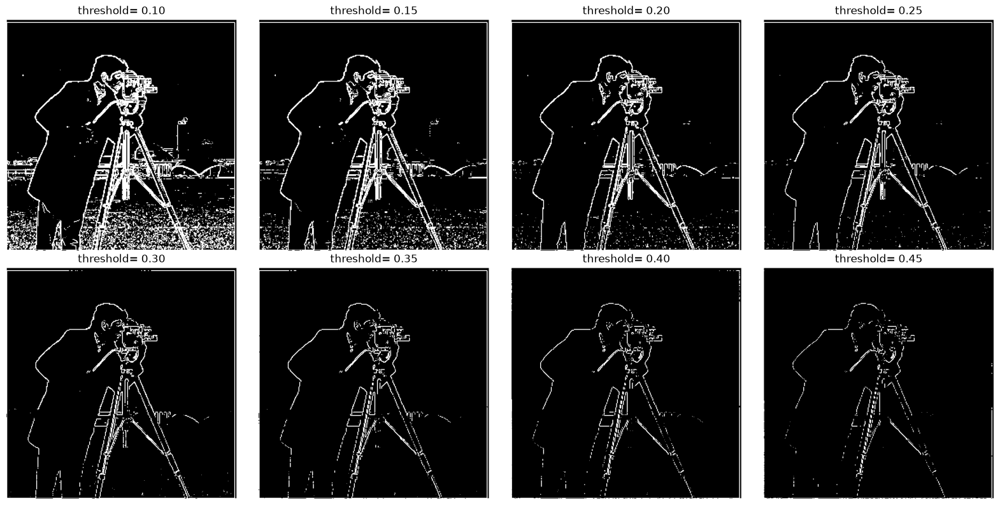

In [37]:
# 1.2

cameraman = img_as_float(imread("img/cameraman.png"))
if cameraman.ndim == 3:
    cameraman = color.rgb2gray(cameraman[..., :3])

print("shape:", cameraman.shape)
print("intensity range:", cameraman.min(), "-", cameraman.max())

cam_dx = convolve2d(cameraman, Dx, mode="same", boundary="fill", fillvalue=0)
cam_dy = convolve2d(cameraman, Dy, mode="same", boundary="fill", fillvalue=0)

cam_magnitude = np.sqrt(cam_dx**2 + cam_dy**2)

thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45]

fig, axes = plt.subplots(2, math.ceil(len(thresholds)/2), figsize=(16, 8))

axes = axes.flatten()

for ax, threshold in zip(axes, thresholds):
    candidate_edges = cam_magnitude > threshold

    ax.imshow(candidate_edges, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"threshold= {threshold:.2f}")
    ax.axis("off")

plt.tight_layout()
fig.savefig(out_dir / "1_2_threshold_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

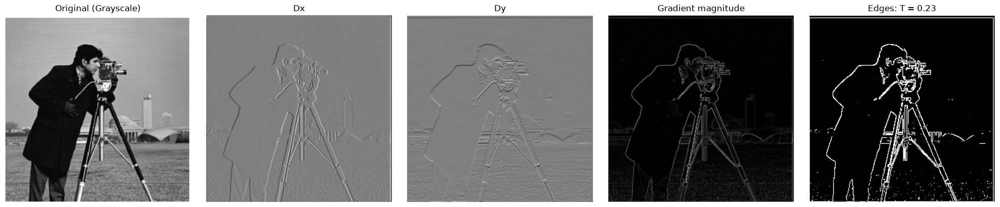

In [76]:
# with chosen threshold
chosen_threshold = 0.23
cam_edges = cam_magnitude > chosen_threshold

d_limit = max(np.max(np.abs(cam_dx)), np.max(np.abs(cam_dy)), 1e-12)

mag_limit = max(np.max(cam_magnitude), 1e-12)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].imshow(cameraman, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original (Grayscale)")

axes[1].imshow(cam_dx, cmap="gray", vmin=-d_limit, vmax=d_limit)
axes[1].set_title("Dx")

axes[2].imshow(cam_dy, cmap="gray", vmin=-d_limit, vmax=d_limit)
axes[2].set_title("Dy")

axes[3].imshow(cam_magnitude, cmap="gray", vmin=0, vmax=mag_limit)
axes[3].set_title("Gradient magnitude")

axes[4].imshow(cam_edges, cmap="gray", vmin=0, vmax=1)
axes[4].set_title(f"Edges: T = {chosen_threshold:.2f}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
fig.savefig(out_dir / "1_2_chosen_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

plt.imsave(out_dir / "cameraman_original.png", cameraman, cmap="gray", vmin=0, vmax=1)

plt.imsave(out_dir / "cameraman_dx.png", cam_dx, cmap="gray", vmin=-d_limit, vmax=d_limit)

plt.imsave(out_dir / "cameraman_dy.png", cam_dy, cmap="gray", vmin=-d_limit, vmax=d_limit)

plt.imsave(out_dir / "cameraman_gradient_magnitude.png", cam_magnitude, cmap="gray", vmin=0, vmax=mag_limit)

plt.imsave(out_dir / "cameraman_edges.png", cam_edges, cmap="gray", vmin=0, vmax=1)

gaussian shape: (11, 11)
gaussian sum: 1.0000000000000002


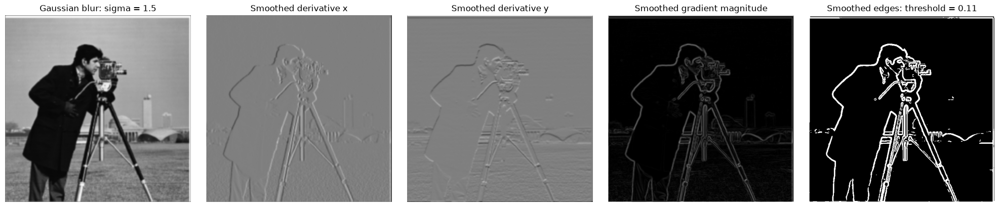

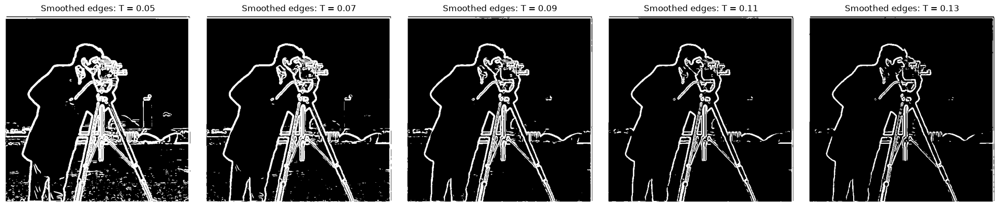

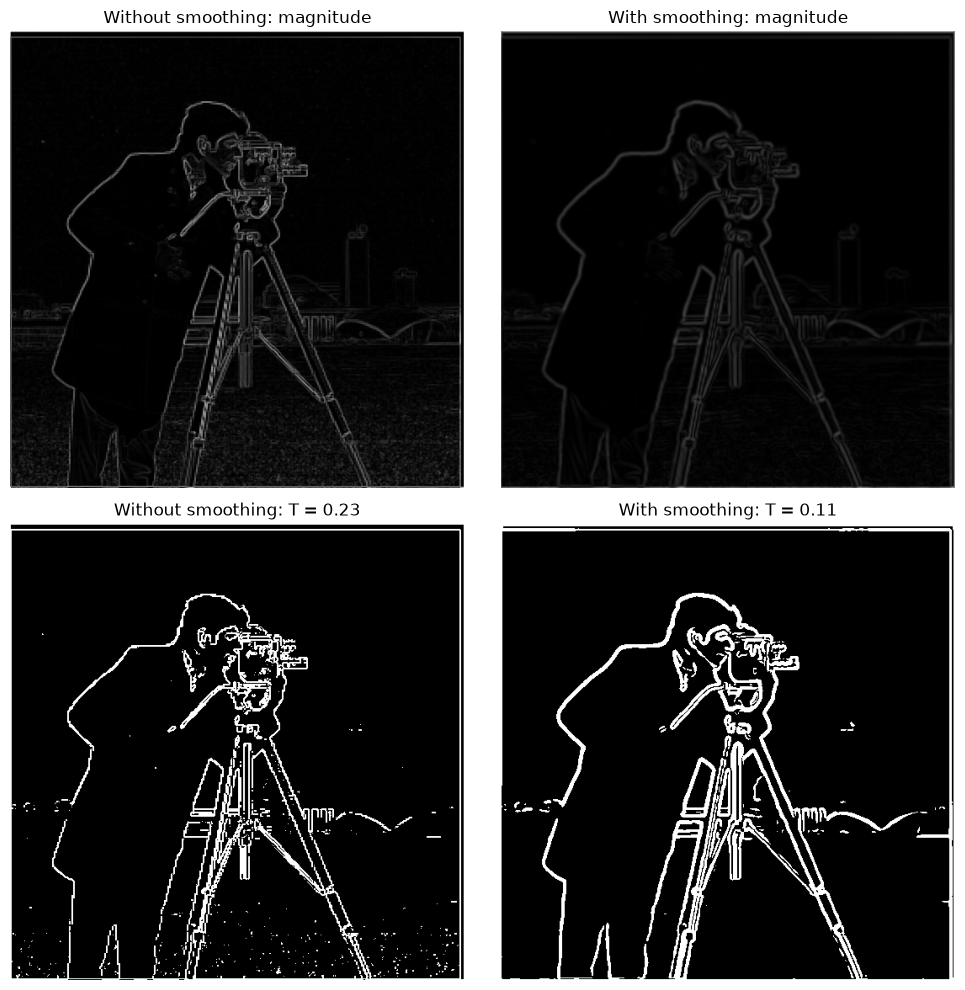

In [89]:
sigma = 1.5
radius = int(np.ceil(3*sigma))
kernel_size = 2 * radius + 1

gaussian_1d = cv2.getGaussianKernel(kernel_size, sigma)

G = gaussian_1d @ gaussian_1d.T

print("gaussian shape:", G.shape)
print("gaussian sum:", G.sum())

cam_blur = convolve2d(cameraman, G, mode="same", boundary="fill", fillvalue=0)
smooth_dx = convolve2d(cam_blur, Dx, mode="same", boundary="fill", fillvalue=0)
smooth_dy = convolve2d(cam_blur, Dy, mode="same", boundary="fill", fillvalue=0)

smooth_magnitude = np.sqrt(smooth_dx**2 + smooth_dy**2)

# first tested with smooth_threshold = 0.05 and got 1_3_smoothed_results_first.png
smooth_threshold = 0.11
smooth_edges = smooth_magnitude > smooth_threshold

d_limit = max(np.max(np.abs(smooth_dx)), np.max(np.abs(smooth_dy)), 1e-12)
smooth_mag_limit = max(smooth_magnitude.max(), 1e-12)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].imshow(cam_blur, cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Gaussian blur: sigma = {sigma}")

axes[1].imshow(smooth_dx, cmap="gray", vmin=-d_limit, vmax=d_limit)
axes[1].set_title("Smoothed derivative x")

axes[2].imshow(smooth_dy, cmap="gray", vmin=-d_limit, vmax=d_limit)
axes[2].set_title("Smoothed derivative y")

axes[3].imshow(smooth_magnitude, cmap="gray", vmin=0, vmax=smooth_mag_limit)
axes[3].set_title("Smoothed gradient magnitude")

axes[4].imshow(smooth_edges, cmap="gray", vmin=0, vmax=1)
axes[4].set_title(f"Smoothed edges: threshold = {smooth_threshold}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
fig.savefig(
    out_dir / "1_3_smoothed_results.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

thresholds = [0.05, 0.07, 0.09, 0.11, 0.13]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, threshold in zip(axes, thresholds):
    ax.imshow(smooth_magnitude > threshold, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Smoothed edges: T = {threshold:.2f}")
    ax.axis("off")

plt.tight_layout()
fig.savefig(out_dir / "1_3_threshold_testing.png", dpi=150, bbox_inches="tight")
plt.show()

shared_mag_limit = max(cam_magnitude.max(), smooth_magnitude.max(), 1e-12)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(cam_magnitude, cmap="gray", vmin=0, vmax=shared_mag_limit)
axes[0, 0].set_title("Without smoothing: magnitude")

axes[0, 1].imshow(smooth_magnitude, cmap="gray", vmin=0, vmax=shared_mag_limit)
axes[0, 1].set_title("With smoothing: magnitude")

axes[1, 0].imshow(cam_edges, cmap="gray", vmin=0, vmax=1)
axes[1, 0].set_title(f"Without smoothing: T = {chosen_threshold}")

axes[1, 1].imshow(smooth_edges, cmap="gray", vmin=0, vmax=1)
axes[1, 1].set_title(f"With smoothing: T = {smooth_threshold}")

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
fig.savefig(out_dir / "1_3_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

DoG x shape: (11, 13)
DoG y shape: (13, 11)
DoG x sum: 1.179069862577986e-17
DoG y sum: -1.1102230246251565e-16


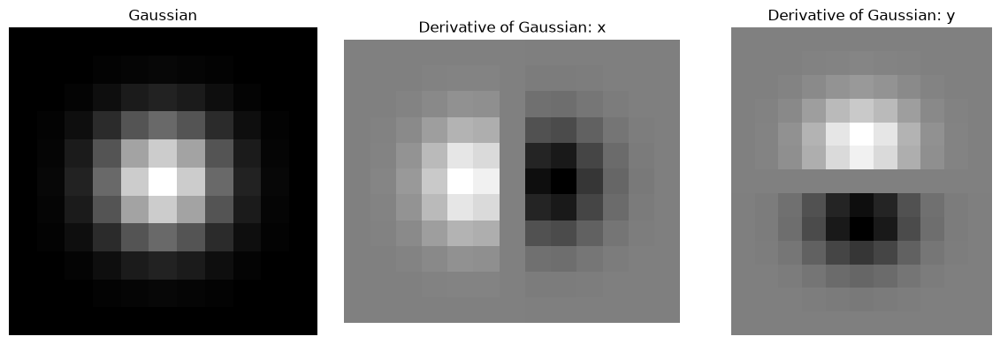

Interior maximum difference, x: 9.992007221626409e-16
Interior maximum difference, y: 1.1466522176206695e-15
Full-preserving sequential filtering matches DoG filtering.


In [92]:
DoG_x = convolve2d(G, Dx, mode="full")
DoG_y = convolve2d(G, Dy, mode="full")

print("DoG x shape:", DoG_x.shape)
print("DoG y shape:", DoG_y.shape)
print("DoG x sum:", DoG_x.sum())
print("DoG y sum:", DoG_y.sum())


dog_dx = convolve2d(cameraman, DoG_x, mode="same", boundary="fill", fillvalue=0)
dog_dy = convolve2d(cameraman, DoG_y, mode="same", boundary="fill", fillvalue=0)

dog_magnitude = np.sqrt(dog_dx**2 + dog_dy**2)
dog_edges = dog_magnitude > smooth_threshold

kernel_limit = max(np.max(np.abs(DoG_x)), np.max(np.abs(DoG_y)), 1e-12)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(G, cmap="gray", interpolation="nearest")
axes[0].set_title("Gaussian")

axes[1].imshow(DoG_x, cmap="gray", vmin=-kernel_limit, vmax=kernel_limit, interpolation="nearest")
axes[1].set_title("Derivative of Gaussian: x")

axes[2].imshow(DoG_y, cmap="gray", vmin=-kernel_limit, vmax=kernel_limit, interpolation="nearest")
axes[2].set_title("Derivative of Gaussian: y")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
fig.savefig(out_dir / "part1_3_kernels.png", dpi=150, bbox_inches="tight")
plt.show()

interior = np.s_[1:-1, 1:-1]

error_x = np.max(np.abs(smooth_dx[interior] - dog_dx[interior]))
error_y = np.max(np.abs(smooth_dy[interior] - dog_dy[interior]))

print("Interior maximum difference, x:", error_x)
print("Interior maximum difference, y:", error_y)

np.testing.assert_allclose(smooth_dx[interior], dog_dx[interior], atol=1e-12)
np.testing.assert_allclose(smooth_dy[interior], dog_dy[interior], atol=1e-12)

blurred_full = convolve2d(cameraman, G, mode="full")

sequential_full_x = convolve2d(blurred_full, Dx, mode="full")
sequential_full_y = convolve2d(blurred_full, Dy, mode="full")

def crop_to_original(full_result, combined_kernel):
    start_y = (combined_kernel.shape[0] - 1) // 2
    start_x = (combined_kernel.shape[1] - 1) // 2
    height, width = cameraman.shape

    return full_result[
        start_y:start_y + height,
        start_x:start_x + width,
    ]

sequential_x = crop_to_original(sequential_full_x, DoG_x)
sequential_y = crop_to_original(sequential_full_y, DoG_y)

np.testing.assert_allclose(sequential_x, dog_dx, atol=1e-12)
np.testing.assert_allclose(sequential_y, dog_dy, atol=1e-12)

print("Full-preserving sequential filtering matches DoG filtering.")

In [94]:
plt.imsave(out_dir / "cameraman_blurred.png", cam_blur, cmap="gray", vmin=0, vmax=1)

plt.imsave(out_dir / "cameraman_smoothed_magnitude.png", smooth_magnitude, cmap="gray",vmin=0, vmax=shared_mag_limit)

plt.imsave(out_dir / "cameraman_smoothed_edges.png", smooth_edges, cmap="gray", vmin=0, vmax=1)

plt.imsave(out_dir / "dog_kernel_x.png", DoG_x, cmap="gray", vmin=-kernel_limit, vmax=kernel_limit)

plt.imsave(out_dir / "dog_kernel_y.png", DoG_y, cmap="gray", vmin=-kernel_limit, vmax=kernel_limit)

plt.imsave(out_dir / "cameraman_dog_magnitude.png", dog_magnitude, cmap="gray", vmin=0, vmax=shared_mag_limit)

plt.imsave(out_dir / "cameraman_dog_edges.png", dog_edges, cmap="gray", vmin=0, vmax=1)

max difference: 1.5543122344752192e-15
Sharpening kernel sum: 1.0


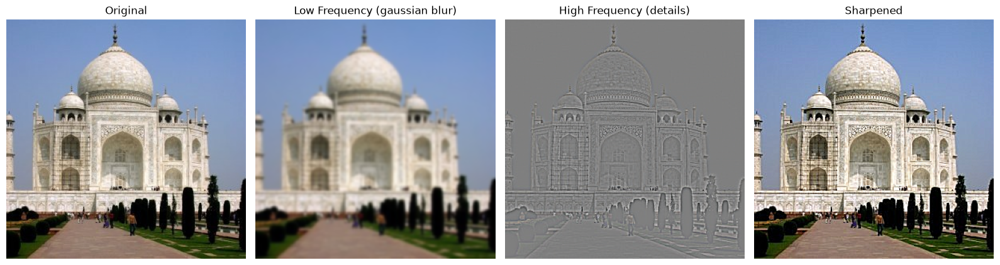

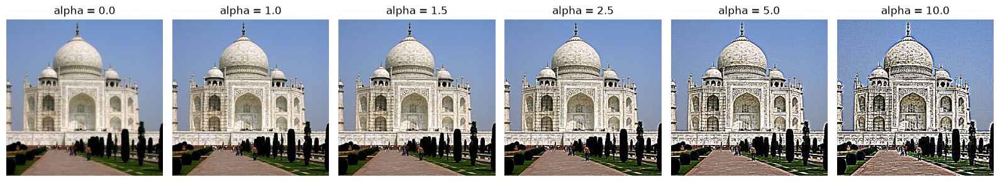

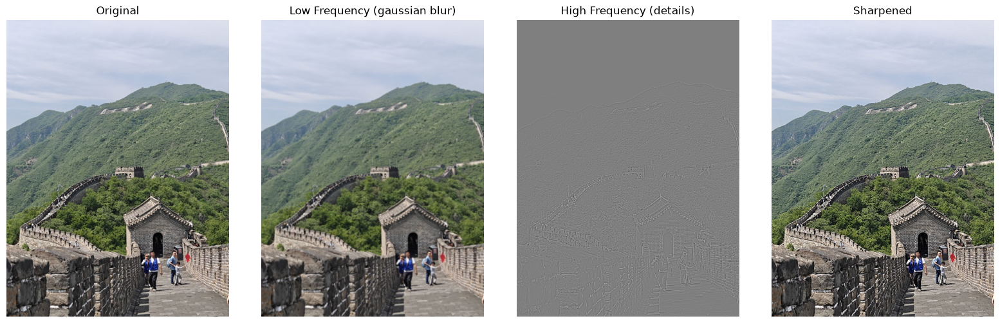

In [115]:
# 2.1
def load_image(path):
    image = img_as_float(imread(path))
    if image.ndim == 3 and image.shape[-1] == 4:
        image = image[..., :3]
    return image

def gaussian_kernel(sigma):
    if sigma <= 0:
        raise ValueError("use positive sigma")

    radius = int(np.ceil(3 * sigma))
    size = 2 * radius + 1

    g = cv2.getGaussianKernel(size, sigma)
    return g @ g.T

def filter_image(image, kernel):
    if image.ndim == 2:
        return convolve2d(image, kernel, mode="same", boundary="symm")

    return np.stack([convolve2d(image[..., channel], kernel, mode="same", boundary="symm") for channel in range(image.shape[-1])], axis=-1)

def unsharp_mask(image, sigma=1.5, alpha=1.0):
    G = gaussian_kernel(sigma)
    identity_kernel = np.zeros_like(G)
    identity_kernel[G.shape[0] // 2, G.shape[1] // 2] = 1.0

    sharpening_kernel = (1 + alpha) * identity_kernel - alpha * G

    blurred = filter_image(image, G)
    details = image - blurred

    sharpened = filter_image(image, sharpening_kernel)

    return blurred, details, sharpened, sharpening_kernel

def detail_display(details):
    limit = max(np.max(np.abs(details)), 1e-12)

    return np.clip(0.5 + details / (2 * limit), 0, 1)

def show_image(ax, image, title):
    if image.ndim == 2:
        ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    else:
        ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

def show_sharpening(image, blurred, details, sharpened, name):
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))

    show_image(axes[0], image, "Original")
    show_image(axes[1], np.clip(blurred, 0, 1), "Low Frequency (gaussian blur)")
    show_image(axes[2], detail_display(details), "High Frequency (details)")
    show_image(axes[3], np.clip(sharpened, 0, 1), "Sharpened")

    plt.tight_layout()
    fig.savefig(out_dir / f"{name}_sharpening_process.png", dpi=150, bbox_inches="tight")
    plt.show()

def save_image(filename, image):
    image = np.clip(image, 0, 1)
    if image.ndim == 2:
        plt.imsave(out_dir / filename, image, cmap="gray", vmin=0, vmax=1)
    else:
        plt.imsave(out_dir / filename, image)

taj = load_image("img/taj.jpg")

sharpen_sigma = 1.5
sharpen_alpha = 1.0

taj_blurred, taj_details, taj_sharpened, taj_kernel = unsharp_mask(taj, sigma=sharpen_sigma, alpha=sharpen_alpha)

expected = taj + sharpen_alpha * taj_details

print("max difference:", np.max(np.abs(taj_sharpened - expected)))

np.testing.assert_allclose(taj_sharpened, expected, atol=1e-12)
print("Sharpening kernel sum:", taj_kernel.sum())

show_sharpening(taj, taj_blurred, taj_details, taj_sharpened, "taj")

alphas = [0.0, 1.0, 1.5, 2.5, 5.0, 10.0]

fig, axes = plt.subplots(1, len(alphas), figsize=(16, 5))
for ax, alpha in zip(axes, alphas):
    blurred, details, sharpened, s_kernel = unsharp_mask(taj, sigma=sharpen_sigma, alpha=alpha)
    show_image(ax, np.clip(sharpened, 0, 1), f"alpha = {alpha}")
plt.tight_layout()
fig.savefig(out_dir / "taj_alpha_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

gwoc = load_image("img/gwoc.jpg")

gwoc_blurred, gwoc_details, gwoc_sharpened, gwoc_s_kernel = unsharp_mask(gwoc, sigma=1.5, alpha=1.0)

show_sharpening(gwoc, gwoc_blurred, gwoc_details, gwoc_sharpened, "gwoc")

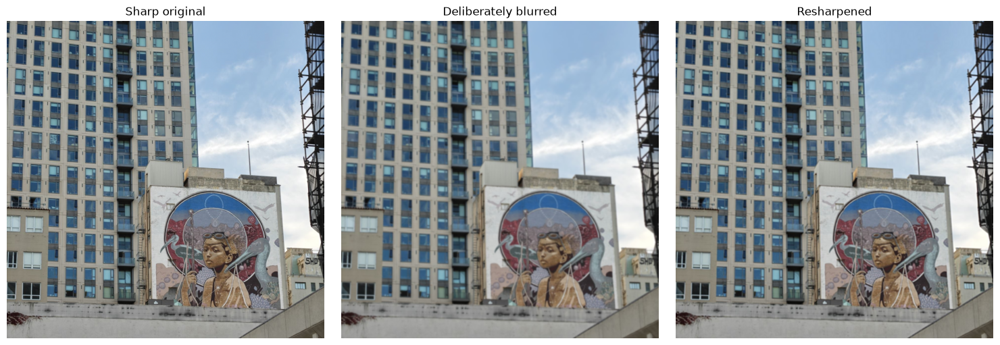

In [118]:
mural_original = load_image("img/mural.jpg")

blur_sigma = 2.0
mural_blurred = filter_image(mural_original, gaussian_kernel(blur_sigma))

mb_blurred, mb_details, mb_sharpened, mb_s_kernel = unsharp_mask(mural_blurred, sigma=1.5, alpha=1.5)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

show_image(axes[0], mural_original, "Sharp original")
show_image(axes[1], mural_blurred, "Deliberately blurred")
show_image(axes[2], np.clip(mb_sharpened, 0, 1), "Resharpened")

plt.tight_layout()
fig.savefig(out_dir / "mural_blur_then_resharpen.png", dpi=150, bbox_inches="tight")
plt.show()

In [119]:
save_image("taj_original.png", taj)
save_image("taj_blurred.png", taj_blurred)
save_image("taj_details.png", detail_display(taj_details))
save_image("taj_sharpened.png", taj_sharpened)

save_image("gwoc.png", gwoc)
save_image("gwoc_blurred.png", gwoc_blurred)
save_image("gwoc_details.png", detail_display(gwoc_details))
save_image("gwoc_sharpened.png", gwoc_sharpened)

save_image("mural_original.png", mural_original)
save_image("mural_blurred.png", mural_blurred)
save_image("mural_resharpened.png", mb_sharpened)

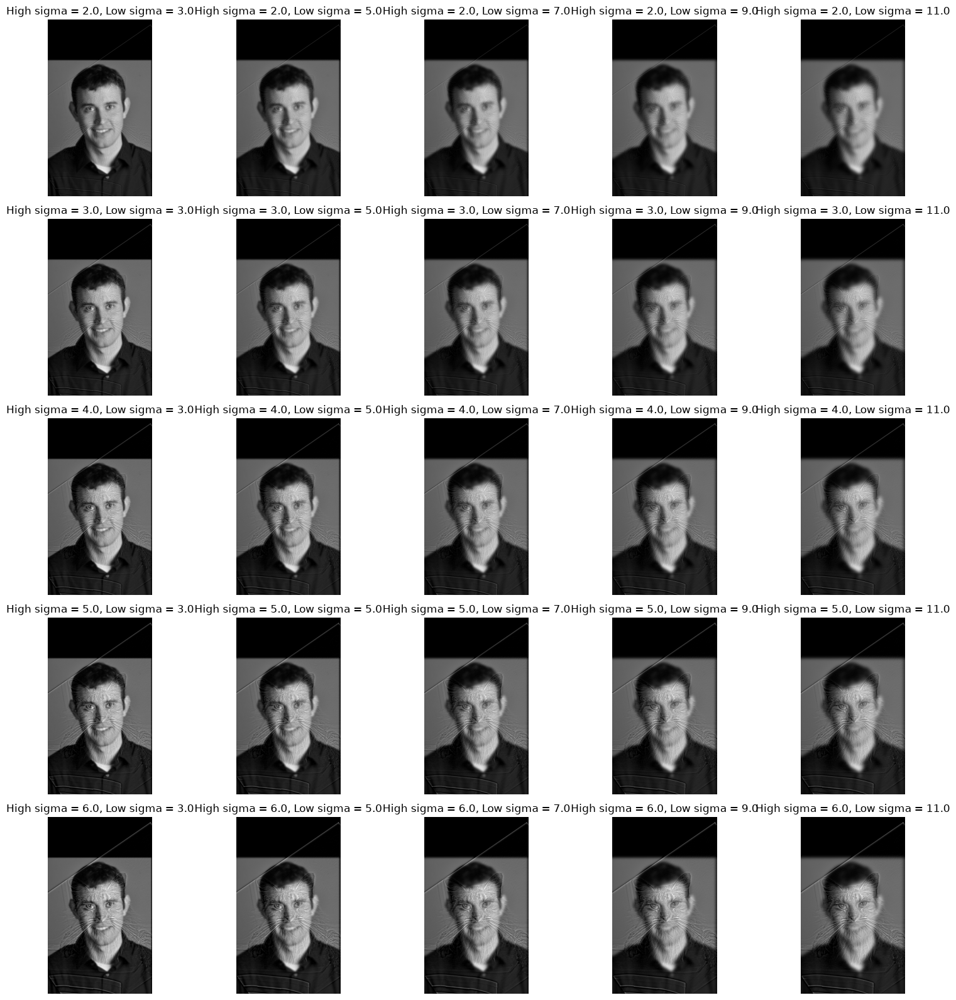

In [3]:
# 2.2
from hybrid_image import hybrid_image

output_dir = Path("outputs/cutoff_trials")
output_dir.mkdir(parents=True, exist_ok=True)

high_sigmas = [2.0, 3.0, 4.0, 5.0, 6.0]
low_sigmas = [3.0, 5.0, 7.0, 9.0, 11.0]

data = np.load("outputs/derek_nutmeg/hybrid_arrays.npz")

im1_aligned = data["aligned_high"]
im2_aligned = data["aligned_low"]

fig, axes = plt.subplots(
    len(high_sigmas),
    len(low_sigmas),
    figsize=(16, 16),
    squeeze=False,
)

for row, sigma_high in enumerate(high_sigmas):
    for col, sigma_low in enumerate(low_sigmas):
        # Your updated function returns three arrays.
        hybrid, high_pass, low_pass = hybrid_image(
            im1_aligned,  # Derek: high-frequency source.
            im2_aligned,  # Nutmeg: low-frequency source.
            sigma_high,
            sigma_low,
        )

        # Clip only for display/save, not before combining components.
        display = np.clip(hybrid, 0, 1)

        axes[row, col].imshow(
            display, cmap="gray", vmin=0, vmax=1,
        )
        axes[row, col].set_title(
            f"High sigma = {sigma_high}, Low sigma = {sigma_low}"
        )
        axes[row, col].axis("off")

        # Save every candidate individually for full-size inspection.
        plt.imsave(
            output_dir / f"hybrid_high_{sigma_high}_low_{sigma_low}.png",
            display,
            cmap="gray",
            vmin=0,
            vmax=1,
        )

plt.tight_layout()
fig.savefig(
    output_dir / "cutoff_comparison.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

# derek (low sigma = 8) & nutmeg (high sigma = 4)
# gigachad (low sigma = 3) & fatalis (high sigma = 1)
# beatles (low sigma = 3) & kendrick (high sigma = 1.5)

Apple: (300, 300, 3)
Orange: (300, 300, 3)
Gaussian stack: (6, 300, 300, 3)
Laplacian stack: (6, 300, 300, 3)


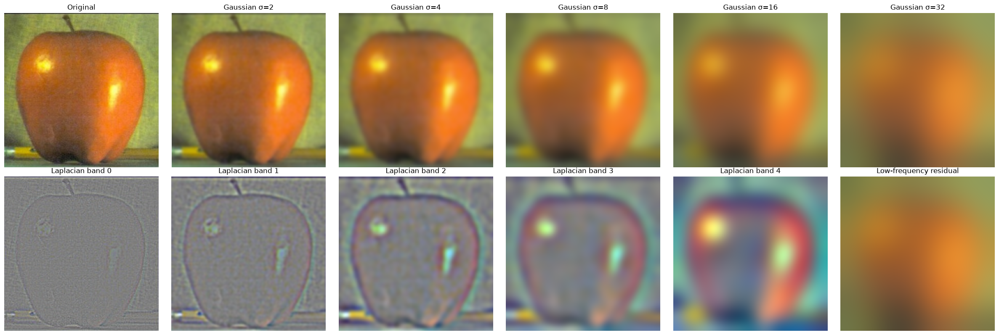

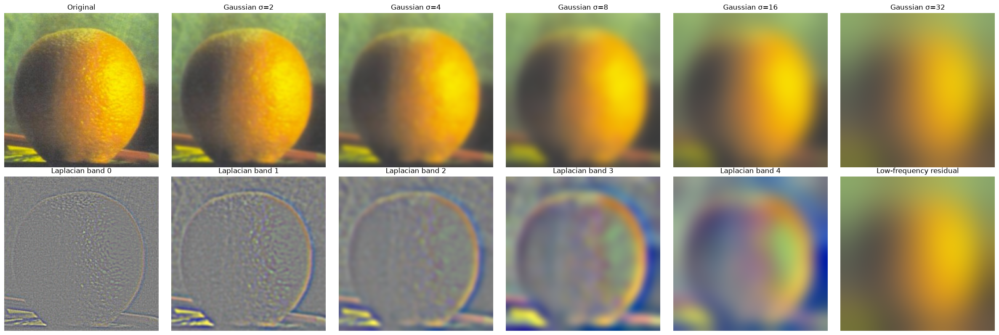

In [4]:
output_dir = Path("out/part2_3")
output_dir.mkdir(parents=True, exist_ok=True)

def load_rgb(path):
    image = img_as_float(imread(path))
    if image.ndim == 2:
        image = np.repeat(image[..., None], 3, axis=-1)

    return image[..., :3]

apple = load_rgb("img/apple.jpeg")
orange = load_rgb("img/orange.jpeg")

print("Apple:", apple.shape)
print("Orange:", orange.shape)

def gaussian_blur_stack(image, sigma):
    radius = int(np.ceil(3 * sigma))
    size = 2 * radius + 1

    g = cv2.getGaussianKernel(size, sigma).ravel()

    def blur_channel(channel):
        # first blur horizontally, then vertically.
        horizontal = convolve2d(channel, g[None, :], mode="same", boundary="symm")
        return convolve2d(horizontal, g[:, None], mode="same", boundary="symm")

    if image.ndim == 2:
        return blur_channel(image)

    return np.stack([blur_channel(image[..., c]) for c in range(image.shape[-1])],axis=-1)


def gaussian_stack(image, levels=6, base_sigma=2.0):
    # G[0] is original, subsequent levels blur by doubling sigmas
    if levels < 2 or base_sigma <= 0:
        raise ValueError("Use levels >= 2 and base_sigma > 0.")

    image = np.asarray(image, dtype=np.float64)
    stack = [image.copy()]

    for level in range(1, levels):
        sigma = base_sigma * 2**(level - 1)
        stack.append(gaussian_blur_stack(image, sigma))

    return np.stack(stack, axis=0)


def laplacian_stack(G):
    # neighboring gaussian differences plus the low-frequency residual
    bands = G[:-1] - G[1:]

    # preserve the final gaussian image so reconstruction is possible
    return np.concatenate([bands, G[-1:]], axis=0)

def signed_display(image, limit):
    """Display mapping only: zero becomes middle gray."""
    return np.clip(0.5 + image / (2 * max(limit, 1e-12)), 0, 1)


def show_stacks(G, L, name):
    count = len(G)
    fig, axes = plt.subplots(2, count, figsize=(4 * count, 8))

    for level in range(count):
        if level == 0:
            gaussian_title = "Original"
        else:
            sigma = base_sigma * 2**(level - 1)
            gaussian_title = f"Gaussian σ={sigma:g}"

        gaussian_display = np.clip(G[level], 0, 1)

        # The last Laplacian level is a normal low-pass image.
        if level == count - 1:
            laplacian_display = np.clip(L[level], 0, 1)
            laplacian_title = "Low-frequency residual"
        else:
            limit = np.max(np.abs(L[level]))
            laplacian_display = signed_display(L[level], limit)
            laplacian_title = f"Laplacian band {level}"

        axes[0, level].imshow(gaussian_display)
        axes[0, level].set_title(gaussian_title)

        axes[1, level].imshow(laplacian_display)
        axes[1, level].set_title(laplacian_title)

        for row in [0, 1]:
            axes[row, level].axis("off")

        plt.imsave(output_dir / f"{name}_gaussian_{level}.png", gaussian_display)
        plt.imsave(output_dir / f"{name}_laplacian_{level}.png", laplacian_display)

    plt.tight_layout()
    fig.savefig(output_dir / f"{name}_stacks.png", dpi=150, bbox_inches="tight")
    plt.show()

levels = 6
base_sigma = 2.0

G_apple = gaussian_stack(apple, levels, base_sigma)
G_orange = gaussian_stack(orange, levels, base_sigma)

L_apple = laplacian_stack(G_apple)
L_orange = laplacian_stack(G_orange)

print("Gaussian stack:", G_apple.shape)
print("Laplacian stack:", L_apple.shape)

show_stacks(G_apple, L_apple, "apple")
show_stacks(G_orange, L_orange, "orange")

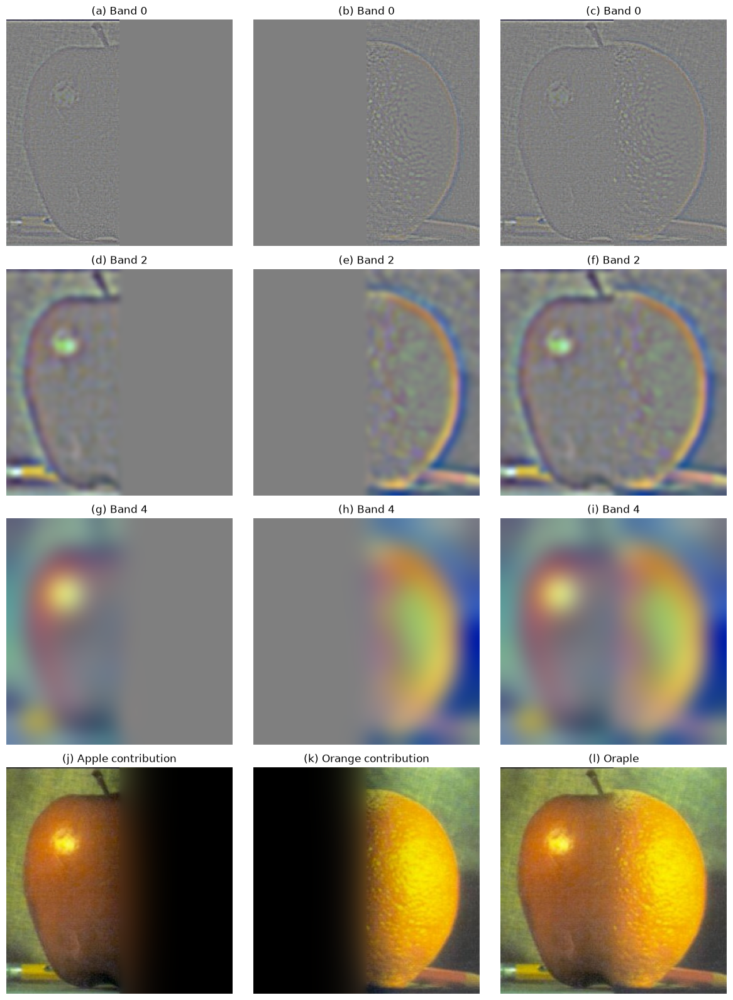

In [5]:
height, width = apple.shape[:2]

# mask: 1 selects apple, 0 selects orange
mask = np.zeros((height, width), dtype=np.float64)
mask[:, :width // 2] = 1.0

# same scale schedule as the image stacks
G_mask = gaussian_stack(mask, levels, base_sigma)

# add a singleton color axis for RGB broadcasting
weights = G_mask[..., None]

apple_contributions = weights * L_apple
orange_contributions = (1 - weights) * L_orange
blended_bands = apple_contributions + orange_contributions

# stack reconstruction is a sum so no upsampling is needed
apple_total = apple_contributions.sum(axis=0)
orange_total = orange_contributions.sum(axis=0)
oraple = blended_bands.sum(axis=0)

selected_levels = [0, 2, 4]
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for row, level in enumerate(selected_levels):
    panels = [apple_contributions[level], orange_contributions[level], blended_bands[level]]

    # Shared scale within each row keeps the contributions comparable.
    limit = max(np.max(np.abs(panel)) for panel in panels)

    for col, panel in enumerate(panels):
        display = signed_display(panel, limit)
        letter = chr(ord("a") + row * 3 + col)

        axes[row, col].imshow(display)
        axes[row, col].set_title(f"({letter}) Band {level}")

        plt.imsave(output_dir / f"figure_3_42_{letter}.png", display)

# Last row: summed contributions, not individual bands.
for col, (panel, label) in enumerate(zip(
    [apple_total, orange_total, oraple],
    ["Apple contribution", "Orange contribution", "Oraple"],
)):
    letter = chr(ord("j") + col)
    display = np.clip(panel, 0, 1)

    axes[3, col].imshow(display)
    axes[3, col].set_title(f"({letter}) {label}")

    plt.imsave(output_dir / f"figure_3_42_{letter}.png", display)

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
fig.savefig(output_dir / "figure_3_42_recreation.png", dpi=150, bbox_inches="tight")
plt.show()

plt.imsave(output_dir / "oraple.png", np.clip(oraple, 0, 1))

In [6]:
def blend(A, B, mask, levels=6, base_sigma=2.0):
    # mask must be 2d array in [0, 1]
    # white select A, black select B
    A = np.asarray(A, dtype=np.float64)
    B = np.asarray(B, dtype=np.float64)
    mask = np.asarray(mask, dtype=np.float64)

    if A.shape != B.shape or A.ndim != 3 or B.ndim != 3:
        raise ValueError("A and B must be equal-sized rgb images")
    if mask.shape != A.shape[:2]:
        raise ValueError("Mask must match image height and width")
    if not np.isfinite(mask).all() or np.any((mask < 0 ) | (mask > 1)):
        raise ValueError("mask values must be finite and within [0, 1]")

    GA = gaussian_stack(A, levels, base_sigma)
    GB = gaussian_stack(B, levels, base_sigma)
    LA = laplacian_stack(GA)
    LB = laplacian_stack(GB)

    GM = gaussian_stack(mask, levels, base_sigma)
    weights = GM[..., None]

    contribution_A = weights * LA
    contribution_B = (1 - weights) * LB
    blended_stack = contribution_A + contribution_B
    
    result = blended_stack.sum(axis=0)

    intermediates = {
        "mask_stack": GM,
        "laplacian_A": LA,
        "laplacian_B": LB,
        "contribution_A": contribution_A,
        "contribution_B": contribution_B,
        "blended_stack": blended_stack,
    }

    return result, intermediates

In [7]:
height, width = apple.shape[:2]

vertical_mask = np.zeros((height, width))
vertical_mask[:, :width // 2] = 1.0

oraple, oraple_info = blend(
    apple,
    orange,
    vertical_mask,
    levels=6,
    base_sigma=2.0,
)

# All-white mask should reconstruct A.
all_A, _ = blend(
    apple, orange, np.ones((height, width)),
)
np.testing.assert_allclose(all_A, apple, atol=1e-12)

# All-black mask should reconstruct B.
all_B, _ = blend(
    apple, orange, np.zeros((height, width)),
)
np.testing.assert_allclose(all_B, orange, atol=1e-12)

print("Mask endpoint checks passed.")

Mask endpoint checks passed.


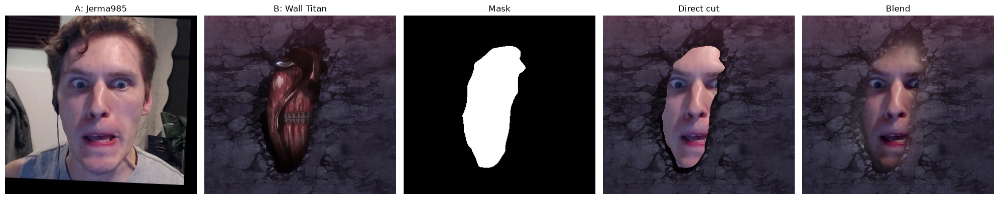

In [16]:
def load_gray(path):
    image = img_as_float(imread(path))
    return color.rgb2gray(image[..., :3]) if image.ndim == 3 else image

a_jerma = load_rgb("img/jerma_aligned.png")
b_titan = load_rgb("img/titan_aligned.png")
jerma_titan_mask = load_gray("img/jerma_titan_mask.jpg")

output_dir = Path("outputs/jerma_titan")
output_dir.mkdir(parents=True, exist_ok=True)

# plt.imshow(b_titan)
# plt.contour(jerma_titan_mask, levels=[0.5], colors="red")
# plt.title("check mask region")
# plt.axis("off")
# plt.show()

jerma_titan_blend, jerma_titan_info = blend(a_jerma, b_titan, jerma_titan_mask, levels=6, base_sigma=2.0)
direct_cut = (jerma_titan_mask[..., None] * a_jerma + (1 - jerma_titan_mask[..., None]) * b_titan)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, image, title in zip(axes, [a_jerma, b_titan, jerma_titan_mask, direct_cut, jerma_titan_blend], ["A: Jerma985", "B: Wall Titan", "Mask", "Direct cut", "Blend"]):
    if image.ndim == 2:
        ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    else:
        ax.imshow(np.clip(image, 0, 1))

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
fig.savefig(output_dir / "jerma_titan_blend_comparison.png", dpi=500, bbox_inches="tight")
plt.show()

plt.imsave(output_dir / "jerma_titan_direct.png", np.clip(direct_cut, 0, 1))
plt.imsave(output_dir / "jerma_titan_blend.png", np.clip(jerma_titan_blend, 0, 1))

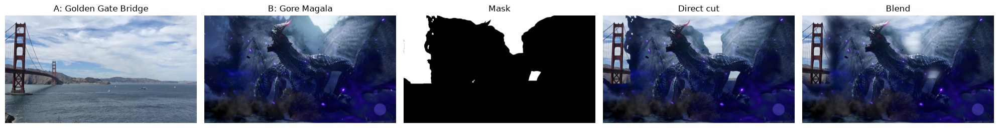

In [20]:
a_gate = load_rgb("img/golden_gate.jpg")
b_gore = load_rgb("img/gore_magala.jpg")
gore_gate_mask = load_gray("img/gore_gate_mask.jpg")

output_dir = Path("outputs/gore_gate")
output_dir.mkdir(parents=True, exist_ok=True)

# plt.imshow(b_gore)
# plt.contour(gore_gate_mask, levels=[0.5], colors="red")
# plt.title("check mask region")
# plt.axis("off")
# plt.show()

gore_gate_blend, gore_gate_info = blend(a_gate, b_gore, gore_gate_mask, levels=6, base_sigma=2.0)
direct_cut = (gore_gate_mask[..., None] * a_gate + (1 - gore_gate_mask[..., None]) * b_gore)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, image, title in zip(axes, [a_gate, b_gore, gore_gate_mask, direct_cut, gore_gate_blend], ["A: Golden Gate Bridge", "B: Gore Magala", "Mask", "Direct cut", "Blend"]):
    if image.ndim == 2:
        ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    else:
        ax.imshow(np.clip(image, 0, 1))

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
fig.savefig(output_dir / "gore_gate_blend_comparison.png", dpi=500, bbox_inches="tight")
plt.show()

plt.imsave(output_dir / "gore_gate_direct.png", np.clip(direct_cut, 0, 1))
plt.imsave(output_dir / "gore_gate_blend.png", np.clip(gore_gate_blend, 0, 1))

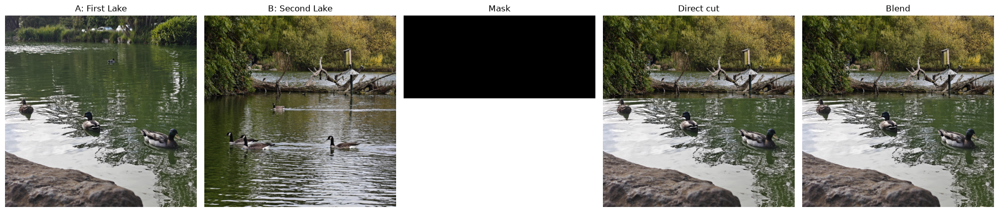

In [22]:
a_lake = load_rgb("img/lake_1.jpg")
b_lake = load_rgb("img/lake_2.jpg")
lake_mask = load_gray("img/lake_mask.jpg")

output_dir = Path("outputs/lakes")
output_dir.mkdir(parents=True, exist_ok=True)

# plt.imshow(b_gore)
# plt.contour(gore_gate_mask, levels=[0.5], colors="red")
# plt.title("check mask region")
# plt.axis("off")
# plt.show()

lake_blend, lake_info = blend(a_lake, b_lake, lake_mask, levels=6, base_sigma=2.0)
direct_cut = (lake_mask[..., None] * a_lake + (1 - lake_mask[..., None]) * b_lake)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, image, title in zip(axes, [a_lake, b_lake, lake_mask, direct_cut, lake_blend], ["A: First Lake", "B: Second Lake", "Mask", "Direct cut", "Blend"]):
    if image.ndim == 2:
        ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    else:
        ax.imshow(np.clip(image, 0, 1))

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
fig.savefig(output_dir / "lake_blend_comparison.png", dpi=500, bbox_inches="tight")
plt.show()

plt.imsave(output_dir / "lake_direct.png", np.clip(direct_cut, 0, 1))
plt.imsave(output_dir / "lake_blend.png", np.clip(lake_blend, 0, 1))

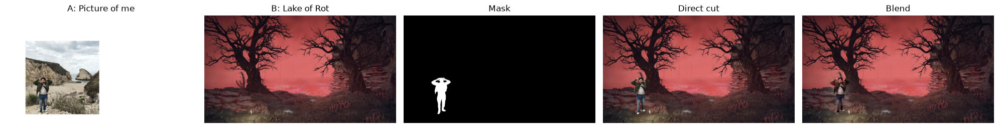

In [27]:
a_me = load_rgb("img/me_2.jpg")
b_rot = load_rgb("img/rot.jpg")
rot_mask = load_gray("img/rot_mask.jpg")

output_dir = Path("outputs/rot")
output_dir.mkdir(parents=True, exist_ok=True)

# plt.imshow(b_gore)
# plt.contour(gore_gate_mask, levels=[0.5], colors="red")
# plt.title("check mask region")
# plt.axis("off")
# plt.show()

rot_blend, rot_info = blend(a_me, b_rot, rot_mask, levels=6, base_sigma=2.0)
direct_cut = (rot_mask[..., None] * a_me + (1 - rot_mask[..., None]) * b_rot)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, image, title in zip(axes, [a_me, b_rot, rot_mask, direct_cut, rot_blend], ["A: Picture of me", "B: Lake of Rot", "Mask", "Direct cut", "Blend"]):
    if image.ndim == 2:
        ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    else:
        ax.imshow(np.clip(image, 0, 1))

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
fig.savefig(output_dir / "rot_blend_comparison.png", dpi=500, bbox_inches="tight")
plt.show()

plt.imsave(output_dir / "rot_direct.png", np.clip(direct_cut, 0, 1))
plt.imsave(output_dir / "rot_blend.png", np.clip(rot_blend, 0, 1))

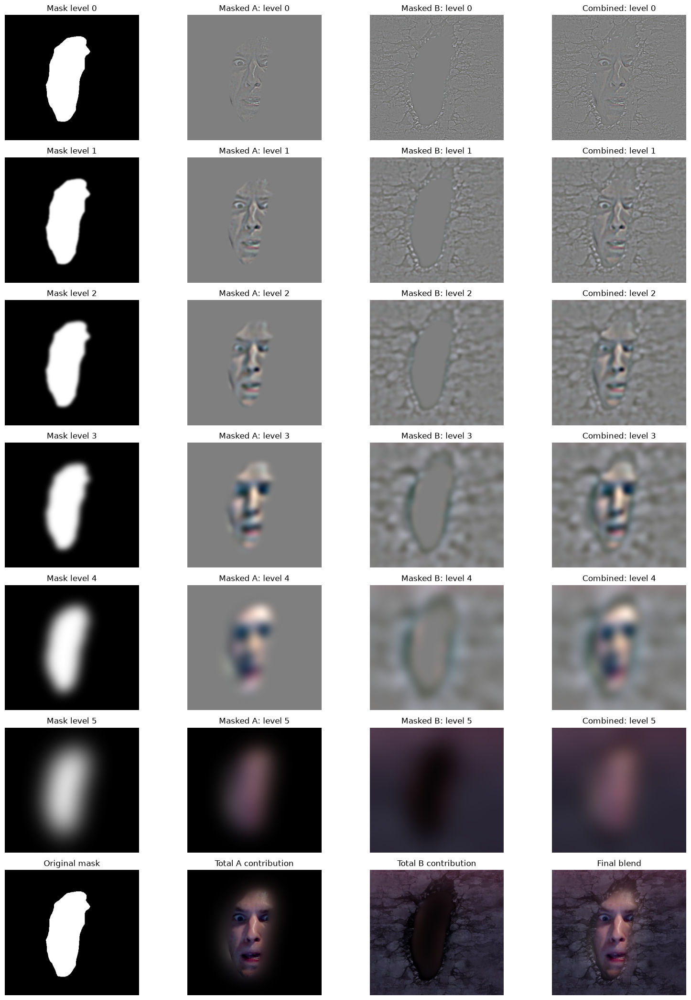

In [30]:
def show_blending_process(info, filename):
    levels = len(info["blended_stack"])

    fig, axes = plt.subplots(levels + 1, 4, figsize=(16, 3 * (levels + 1)), squeeze=False)

    for level in range(levels):
        axes[level, 0].imshow(info["mask_stack"][level], cmap="gray", vmin=0, vmax=1)
        axes[level, 0].set_title(f"Mask level {level}")

        panels = [
            info["contribution_A"][level],
            info["contribution_B"][level],
            info["blended_stack"][level],
        ]

        # shared signed scale for the three contributions at this level
        limit = max(max(np.max(np.abs(panel)) for panel in panels), 1e-12)

        for col, (panel, title) in enumerate(zip(panels, ["Masked A", "Masked B", "Combined"]), start=1):
            # last level is the low-frequency residual
            if level == levels - 1:
                display = np.clip(panel, 0, 1)
            else:
                display = signed_display(panel, limit)

            axes[level, col].imshow(display)
            axes[level, col].set_title(f"{title}: level {level}")

    # reconstruct from raw signed arrays, not display bands
    total_A = info["contribution_A"].sum(axis=0)
    total_B = info["contribution_B"].sum(axis=0)
    final_blend = info["blended_stack"].sum(axis=0)

    axes[-1, 0].imshow(info["mask_stack"][0], cmap="gray", vmin=0, vmax=1)
    axes[-1, 0].set_title("Original mask")

    for col, (image, title) in enumerate(
        zip(
            [total_A, total_B, final_blend],
            ["Total A contribution", "Total B contribution", "Final blend"],
        ),
        start=1,
    ):
        axes[-1, col].imshow(np.clip(image, 0, 1))
        axes[-1, col].set_title(title)

    for ax in axes.ravel():
        ax.axis("off")

    plt.tight_layout()
    fig.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()


show_blending_process(
    jerma_titan_info,
    output_dir / "custom_blending_process.png",
)